In [ ]:
import torch
from torchvision import transforms, models
from torchvision import transforms
from torch.utils.data import Subset, DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import confusion_matrix
import seaborn as sns
import os

In [2]:

from utils.Config import Config

cfg = Config.from_yaml("config.yaml")
cfg

Config(data_path='./res', batch_size=32, learning_rate=0.0001, epochs=15, patience=3, loss='CrossEntropy', optimizer='Adam', fine_tuning=True, use_augmentation=True, resume_training=False, checkpoint_dir='./checkpoints', download_data=False, model_name='Augmentation_4_30_001')

In [3]:
from utils.dataDownloader import download_data

if(cfg.download_data):
    download_data()

In [4]:

# Statistiche standard di ImageNet (usate da ResNet/VGG)
# È fondamentale usare queste se fai Transfer Learning
mean_stats = [0.485, 0.456, 0.406]
std_stats  = [0.229, 0.224, 0.225]

# Data Augmentation per il training set

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),       
    transforms.RandomRotation(15),   
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean_stats, std_stats)
])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),            
    transforms.Normalize(mean_stats, std_stats)
])

In [5]:
from utils.OxfordPets import OxfordPetsDataset

full_train_ds = OxfordPetsDataset(root_dir='res', transform=train_transforms)

full_test_ds = OxfordPetsDataset(root_dir='res', transform=test_transforms)

total_len = len(full_train_ds)
indices = list(range(total_len))

# Necessario perché il dataset è ordinato per razze
np.random.shuffle(indices)

train_split = int(0.7 * total_len)
val_split   = int(0.15 * total_len)
# Il resto va al test

train_indices = indices[:train_split]
val_indices   = indices[train_split : train_split + val_split]
test_indices  = indices[train_split + val_split :]


train_dataset = Subset(full_train_ds, train_indices)

val_dataset   = Subset(full_test_ds, val_indices)

test_dataset  = Subset(full_test_ds, test_indices)

print(f"Train: {len(train_dataset)} immagini")
print(f"Val:   {len(val_dataset)} immagini")
print(f"Test:  {len(test_dataset)} immagini")

Train: 5144 immagini
Val:   1102 immagini
Test:  1103 immagini


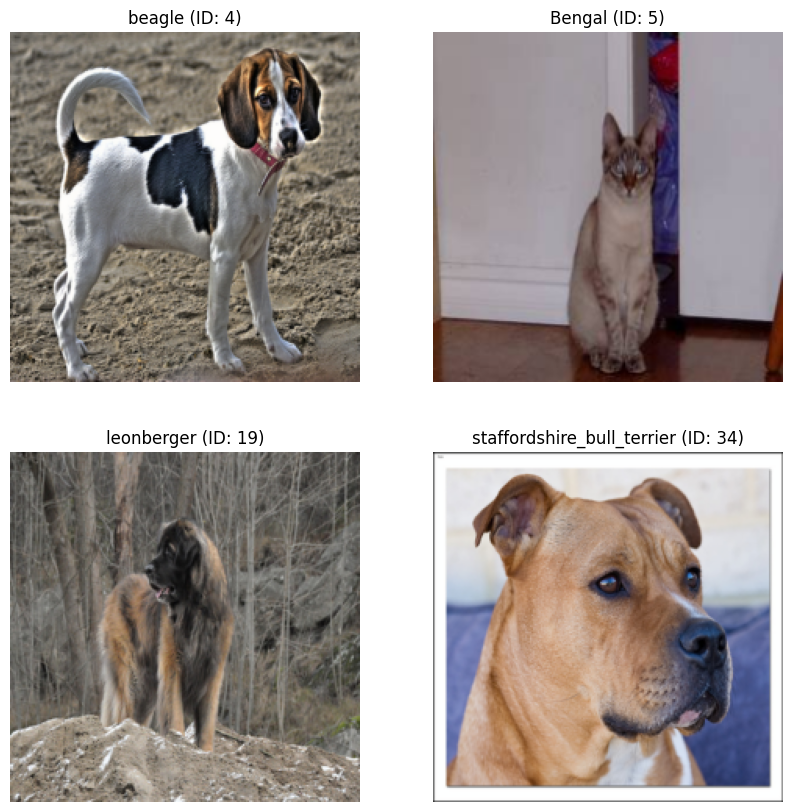

In [6]:

# Mostriamo alcune delle immagini per verificare che siano presenti
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

idx_to_class = {}
with open('res/annotations/list.txt', 'r') as f:
    for line in f:
        if line.startswith('#'): continue
        parts = line.strip().split()
        if len(parts) >= 2:
            breed_name = parts[0].rsplit('_', 1)[0]
            class_id = int(parts[1]) - 1
            idx_to_class[class_id] = breed_name

figure = plt.figure(figsize=(10, 10))
cols, rows = 2, 2

for i in range(1, cols * rows + 1):
    # Le prendiamo dal test set direttamente
    sample_idx = torch.randint(len(test_dataset), size=(1,)).item()
    img, label = test_dataset[sample_idx]
    
    figure.add_subplot(rows, cols, i)
    plt.title(f"{idx_to_class.get(label, label)} (ID: {label})")
    plt.axis("off")
    
    # Operazioni per visualizzare
    img_np = img.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)
    
    plt.imshow(img_np)

plt.show()

In [7]:


class ImprovedCustomCNN(nn.Module):
    def __init__(self):
        super(ImprovedCustomCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) 
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Utilizziamo Dropout per ridurre overfitting, mandando a zero una percentuale di neuroni negli hidden layers
        self.dropout = nn.Dropout(0.5)
        
        # Calcolo dimensione per il layer lineare:
        # Input 224x224
        # Pool1 -> 112
        # Pool2 -> 56
        # Pool3 -> 28
        # Pool4 -> 14
        # Uscita finale: 256 canali * 14 * 14 pixel
        self.flatten_size = 256 * 14 * 14
        
        self.fc1 = nn.Linear(self.flatten_size, 512)
        self.bn_fc1 = nn.BatchNorm1d(512) 
        self.fc2 = nn.Linear(512, 37) # Le classi totali sono 37, quindi servono 37 neuroni nel livello finale

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = self.conv4(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.pool(x)
        
        x = x.view(-1, self.flatten_size)
        
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

model = ImprovedCustomCNN()
# model.to(device)

In [8]:


"""
 Questa classe serve a modellare l'early stopping, quando la loss del training set diminuisce ma quella del validation set sale, 
 stiamo andando incontro al fenomeno dell'overfitting.
 Quando succede per un determinato numero di epoche fermiamo il training e consideriamo come modello allenato l'ultimo prima che iniziasse questo fenomeno.
"""

class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0):
        """
        Args:
            patience (int): Quante epoche aspettare dopo l'ultimo miglioramento.
            verbose (bool): Se True, stampa un messaggio a ogni miglioramento.
            delta (float): Minimo cambiamento da considerare come miglioramento.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Salva il modello quando la validation loss diminuisce.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        self.best_model_wts = model.state_dict() # Salva i pesi in memoria
        self.val_loss_min = val_loss
    
    def load_best_weights(self, model):
        '''Carica i pesi migliori nel modello'''
        model.load_state_dict(self.best_model_wts)

In [ ]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Stiamo usando il dispositivo: {device}")

"""
Utilizziamo un approccio modulare per gestire le varie configurazioni, passando gli argomenti alla seguente funzione e salvando i modelli in memoria
"""

def train_experiment(model, loss_fn, optimizer_class, learning_rate, batch_size, patience, epochs):
    train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size, shuffle=False)
    
    criterion = loss_fn
    optimizer = optimizer_class(model.parameters(), lr=learning_rate)  

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    early_stopping = EarlyStopping(patience, verbose=True)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    start_epoch = 0
    best_acc = 0.0

    if cfg.resume_training:
        checkpoint_path = f'checkpoints/{cfg.model_name}.pth'
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            
            start_epoch = checkpoint['epoch']
            best_acc = checkpoint['best_acc']
            

            train_losses = checkpoint.get('train_losses', [])
            val_losses = checkpoint.get('val_losses', [])
            val_accuracies = checkpoint.get('val_accuracies', [])
            
            print(f"RESUME: Epoca {start_epoch+1}, Best Acc: {best_acc:.2f}%")
            print(f"        Storico caricato: {len(train_losses)} epoche precedenti.")
        else:
            print("RESUME fallito: File non trovato. Inizio da zero.")

    # Training Loop
    for epoch in range(start_epoch, epochs): 
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        
        epoch_train_loss = running_loss / len(train_dataset)
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_dataset)
        epoch_acc = 100 * correct / total
        
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_acc)
        
        if epoch_acc > best_acc:
            best_acc = epoch_acc

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Ep {epoch+1}/{epochs} | LR: {current_lr:.6f} | T_Loss: {epoch_train_loss:.3f} | V_Loss: {epoch_val_loss:.3f} | Acc: {epoch_acc:.2f}%')
        
        scheduler.step(epoch_val_loss)
        early_stopping(epoch_val_loss, model)
        
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_acc,
            'scheduler_state_dict': scheduler.state_dict(),
            
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies
        }
        torch.save(checkpoint, f'checkpoints/{cfg.model_name}.pth')

        if early_stopping.early_stop:
            print("Early stopping!")
            early_stopping.load_best_weights(model)
            break
            
    return best_acc

Stiamo usando il dispositivo: cpu


In [ ]:
if(not cfg.resume_training and os.path.exists(f"checkpoints/{cfg.model_name}.pth")):
    raise ValueError(f"ERRORE: Esiste già un modello con quel nome, cambialo per evitare perdita di dati")

current_loss_fn = cfg.get_loss_fn()        
current_opt_class = cfg.get_optimizer_class() 

if not cfg.resume_training and os.path.exists(f"checkpoints/{cfg.model_name}.pth"):
    raise ValueError(f"ERRORE: Il file checkpoints/{cfg.model_name}.pth esiste già!")

if not cfg.fine_tuning:
    print(">>> TRAIN: CUSTOM CNN")
    model_custom = ImprovedCustomCNN().to(device)
    acc = train_experiment(
        model=model_custom, 
        loss_fn=current_loss_fn,
        optimizer_class=current_opt_class, 
        learning_rate=cfg.learning_rate, 
        batch_size=cfg.batch_size, 
        patience=cfg.patience,          
        epochs=cfg.epochs
    )
else:
    print("\n>>> TRAIN: FINETUNING RESNET")
    resnet = models.resnet18(weights='DEFAULT')
    for param in resnet.parameters():
        param.requires_grad = False 
    resnet.fc = nn.Linear(512, 37)
    resnet = resnet.to(device)

    acc = train_experiment(
        model=resnet, 
        loss_fn=current_loss_fn,          
        optimizer_class=current_opt_class,
        learning_rate=cfg.learning_rate, 
        batch_size=cfg.batch_size, 
        patience=cfg.patience,          
        epochs=cfg.epochs
    )

print(f"Training Finito. Best Accuracy: {acc:.2f}%")

In [ ]:

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

def evaluate_on_test(model_name, model_class, checkpoint_path):
    print(f"\n--- Valutazione: {model_name} ---")
    model = model_class.to(device)
    
    try:
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict']) 
        print(f"Pesi caricati (Epoca {checkpoint['epoch']})")
    except FileNotFoundError:
        print("Errore: File non presente")
        return 0.0

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

final_acc = evaluate_on_test(
    model_name=cfg.model_name,
    model_class=ImprovedCustomCNN() if not cfg.fine_tuning else resnet,
    checkpoint_path=f'checkpoints/{cfg.model_name}.pth'
)
print(f"Accuratezza Test Set: {final_acc:.2f}%")

In [ ]:

if(cfg.fine_tuning):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 37)
else:
    model = ImprovedCustomCNN().to(device)

checkpoint = torch.load(f"checkpoints/{cfg.model_name}.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(20, 18)) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=idx_to_class.values(), 
            yticklabels=idx_to_class.values())

plt.xlabel('Predizione')
plt.ylabel('Verità')
plt.title(f'Matrice di Confusione - {cfg.model_name}')
plt.show()

In [ ]:
class_correct = list(0. for i in range(37))
class_total = list(0. for i in range(37))

for i in range(len(all_labels)):
    label = all_labels[i]
    pred = all_preds[i]
    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0 for i in range(37)]
class_names = [idx_to_class[i] for i in range(37)]

# Plot
plt.figure(figsize=(15, 8))
plt.bar(class_names, class_acc, color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('Accuratezza (%)')
plt.title('Accuratezza per Razza')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def plot_training_history(checkpoint_path):
    """
    Carica un checkpoint e plotta Loss e Accuracy
    """
    if not os.path.exists(checkpoint_path):
        print("Checkpoint non trovato.")
        return

    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    val_accuracies = checkpoint.get('val_accuracies', [])
    
    if not train_losses:
        print("Nessuno storico trovato nel checkpoint.")
        return

    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, val_accuracies, label='Val Accuracy', color='green')
    plt.title('Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.show()

plot_training_history(f"checkpoints/{cfg.model_name}.pth")